In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 데이터셋 로드
df = pd.read_csv('https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv')

# 결측치 제거
df_cleaned = df.dropna()

print("Original data shape:", df.shape)
print("Cleaned data shape (after dropping NaNs):", df_cleaned.shape)
display(df_cleaned.head())

Original data shape: (2938, 22)
Cleaned data shape (after dropping NaNs): (1649, 22)


,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [38]:
# 타겟 변수 정의
target = 'Life expectancy'

# 독립 변수(피처) 정의, 'Schooling' 제외
# 문제 설명에 'Life expectancy' 뒤에 공백이 있으므로 그대로 사용합니다.
# 또한, 정확한 일치를 위해 열 이름을 확인합니다.

# 안전을 위해 먼저 열 이름을 검사합니다.
print("Columns in cleaned DataFrame:", df_cleaned.columns.tolist())

# 문제 설명 및 이 데이터셋의 일반적인 상식을 바탕으로 선택된 피처
features = [
    'Adult mortality', # Corrected: 'Mortality' to 'mortality'
    'BMI',
    'GDP',
    'Alcohol',
    'Polio'
]

# 선택된 모든 피처가 DataFrame에 있는지 확인
missing_features = [f for f in features if f not in df_cleaned.columns]
if missing_features:
    raise ValueError(f"The following selected features are not in the DataFrame: {missing_features}")

X = df_cleaned[features]
y = df_cleaned[target]

print("\nFeatures (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Columns in cleaned DataFrame: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult mortality', 'Infant deaths', 'Alcohol', 'Percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'Thinness 1-19 years', 'Thinness 5-9 years', 'Income composition of resources', 'Schooling']

Features (X) head:


,Adult mortality,BMI,GDP,Alcohol,Polio
0,263.0,19.1,584.259210,0.01,6.0
1,271.0,18.6,612.696514,0.01,58.0
2,268.0,18.1,631.744976,0.01,62.0
3,272.0,17.6,669.959000,0.01,67.0
4,275.0,17.2,63.537231,0.01,68.0



Target (y) head:


,Life expectancy
0,65.0
1,59.9
2,59.9
3,59.5
4,59.2


In [39]:
# 데이터를 훈련 세트 80%, 테스트 세트 20%로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 학습을 위해 훈련 데이터에서 무작위로 50개 샘플 추출
# 훈련 세트에 최소 50개 샘플이 있는지 확인
if X_train.shape[0] >= 50:
    X_train_50 = X_train.sample(n=50, random_state=42)
    y_train_50 = y_train.loc[X_train_50.index] # 해당 타겟 값 선택
    print("\nSelected 50 random samples for training:")
    print("X_train_50 shape:", X_train_50.shape)
    print("y_train_50 shape:", y_train_50.shape)
    display(X_train_50.head())
    display(y_train_50.head())
else:
    print("Warning: Not enough samples in X_train to select 50. Using all available training samples.")
    X_train_50 = X_train
    y_train_50 = y_train
    print("X_train_50 shape:", X_train_50.shape)
    print("y_train_50 shape:", y_train_50.shape)

X_train shape: (1319, 5)
X_test shape: (330, 5)
y_train shape: (1319,)
y_test shape: (330,)

Selected 50 random samples for training:
X_train_50 shape: (50, 5)
y_train_50 shape: (50,)


,Adult mortality,BMI,GDP,Alcohol,Polio
1285,6.0,62.1,34814.124360,7.49,96.0
1566,268.0,15.0,316.799896,0.93,65.0
1949,177.0,2.6,139.312880,0.03,7.0
597,246.0,21.6,769.174288,0.15,82.0
1524,178.0,61.4,15712.823760,15.04,93.0


,Life expectancy
1285,82.0
1566,59.9
1949,64.6
597,61.8
1524,73.0


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
import joblib

# Model 1 (Linear): 1차 항 기본 선형 회귀 파이프라인
# StandardScaler로 스케일링 후 LinearRegression 모델 학습
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

# Model 2 (Poly): 3차 다항 회귀 파이프라인 (규제 없음 -> 과대적합 유도)
# StandardScaler로 스케일링, PolynomialFeatures로 3차 다항 변환 후 LinearRegression 모델 학습
pipeline_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)), # bias=False는 StandardScaler가 이미 intercept를 처리하므로 중복 방지
    ('linear', LinearRegression())
])

# Model 3 (Ridge): 3차 다항 회귀 + 릿지 규제 파이프라인 (alpha=1.0)
# StandardScaler로 스케일링, PolynomialFeatures로 3차 다항 변환 후 Ridge 모델 학습
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])

# 각 모델 학습
print("Model 1 (Linear) 학습 중...")
pipeline_linear.fit(X_train_50, y_train_50)
print("Model 1 (Linear) 학습 완료.")

print("\nModel 2 (Poly) 학습 중...")
pipeline_poly.fit(X_train_50, y_train_50)
print("Model 2 (Poly) 학습 완료.")

print("\nModel 3 (Ridge) 학습 중...")
pipeline_ridge.fit(X_train_50, y_train_50)
print("Model 3 (Ridge) 학습 완료.")


Model 1 (Linear) 학습 중...
Model 1 (Linear) 학습 완료.

Model 2 (Poly) 학습 중...
Model 2 (Poly) 학습 완료.

Model 3 (Ridge) 학습 중...
Model 3 (Ridge) 학습 완료.


In [41]:
# 모델 저장
joblib.dump(pipeline_linear, 'linear_regression_model.pkl')
joblib.dump(pipeline_poly, 'polynomial_regression_model.pkl')
joblib.dump(pipeline_ridge, 'ridge_regression_model.pkl')

print("모든 모델이 .pkl 파일로 저장되었습니다:")
print("- linear_regression_model.pkl")
print("- polynomial_regression_model.pkl")
print("- ridge_regression_model.pkl")

모든 모델이 .pkl 파일로 저장되었습니다:
- linear_regression_model.pkl
- polynomial_regression_model.pkl
- ridge_regression_model.pkl


In [42]:
joblib.dump(X_train_50, 'X_train_50.pkl')
joblib.dump(y_train_50, 'y_train_50.pkl')
joblib.dump(X_test, 'X_test.pkl')
joblib.dump(y_test, 'y_test.pkl')

print("데이터가 .pkl 파일로 저장되었습니다:")
print("- X_train_50.pkl")
print("- y_train_50.pkl")
print("- X_test.pkl")
print("- y_test.pkl")

데이터가 .pkl 파일로 저장되었습니다:
- X_train_50.pkl
- y_train_50.pkl
- X_test.pkl
- y_test.pkl


In [43]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

In [44]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumBarunGothic'
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    st.sidebar.success('나눔고딕 폰트 설정 완료')
else:
    st.sidebar.warning('나눔고딕 폰트 파일을 찾을 수 없습니다. 한글이 깨질 수 있습니다.')


# Streamlit 앱 제목
st.title('생애 기대 수명 예측 및 모델 비교 대시보드')

# --- 데이터 및 모델 로드 ---
st.sidebar.header('데이터 및 모델 로드 상태')
try:
    linear_model = joblib.load('linear_regression_model.pkl')
    poly_model = joblib.load('polynomial_regression_model.pkl')
    ridge_model = joblib.load('ridge_regression_model.pkl')
    st.sidebar.success('모델 로드 성공!')

    X_train_50 = joblib.load('X_train_50.pkl')
    y_train_50 = joblib.load('y_train_50.pkl')
    X_test = joblib.load('X_test.pkl')
    y_test = joblib.load('y_test.pkl')
    st.sidebar.success('데이터 로드 성공!')

except Exception as e:
    st.sidebar.error(f'모델 또는 데이터 로드 실패: {e}')
    st.stop() # 로드 실패 시 앱 중단

models = {
    'Linear Model': linear_model,
    'Polynomial Model': poly_model,
    'Ridge Model': ridge_model
}

# --- 1. 모델 성능 비교 섹션 ([조건 3]) ---
st.header('모델 성능 비교')

performance_metrics = []

for name, model in models.items():
    # 훈련 데이터 예측 및 평가
    y_train_pred = model.predict(X_train_50)
    train_r2 = r2_score(y_train_50, y_train_pred)
    train_mse = mean_squared_error(y_train_50, y_train_pred)

    # 테스트 데이터 예측 및 평가
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 모델 복잡성 (변수 변환 후 특성 개수)
    complexity = X_train_50.shape[1] # 기본 특성 개수
    if 'poly_features' in model.named_steps:
        temp_scaler = model.named_steps['scaler']
        X_scaled_temp = temp_scaler.transform(X_train_50)

        poly_transformer = model.named_steps['poly_features']
        complexity = poly_transformer.transform(X_scaled_temp).shape[1]

    performance_metrics.append({
        'Model': name,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Complexity': complexity
    })

performance_df = pd.DataFrame(performance_metrics)

st.subheader('모델 성능 평가지표 테이블')
st.dataframe(performance_df.round(3))

# 테스트 R^2 점수 비교 시각화
st.subheader('테스트 R^2 점수 비교 시각화')
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['skyblue', 'lightcoral', 'lightgreen']
ax.bar(performance_df['Model'], performance_df['Test R^2'], color=bar_colors)
ax.set_xlabel('모델', fontsize=12)
ax.set_ylabel('R^2 점수', fontsize=12)
ax.set_title('각 모델의 테스트 R^2 점수 비교', fontsize=14)
ax.set_ylim(min(0, performance_df['Test R^2'].min() - 0.1), max(1, performance_df['Test R^2'].max() + 0.1))

for i, v in enumerate(performance_df['Test R^2']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10) # 값 표시

st.pyplot(fig)


# --- 2. 실시간 예측 UI 구성 섹션 ([조건 4]) ---
st.header('실시간 기대 수명 예측')

st.sidebar.header('예측 변수 입력')

# 슬라이더를 위한 입력값
input_adult_mortality = st.sidebar.slider('성인 사망률 (Adult mortality)', 1.0, 750.0, 160.0)
input_bmi = st.sidebar.slider('BMI', 1.0, 80.0, 38.0)
input_gdp = st.sidebar.slider('GDP', 1.0, 120000.0, 7000.0)
input_alcohol = st.sidebar.slider('알코올 소비량 (Alcohol)', 0.0, 18.0, 5.0)
input_polio = st.sidebar.slider('소아마비 예방접종률 (Polio)', 0.0, 100.0, 80.0)

# 입력값을 DataFrame으로 변환
input_data = pd.DataFrame([{
    'Adult mortality': input_adult_mortality,
    'BMI': input_bmi,
    'GDP': input_gdp,
    'Alcohol': input_alcohol,
    'Polio': input_polio
}])

# 모델 선택 인터페이스
selected_model_name = st.selectbox(
    '예측에 사용할 모델을 선택하세요:',
    ('Linear Model', 'Polynomial Model', 'Ridge Model')
)

selected_model = models[selected_model_name]

# 예측 수행
prediction = selected_model.predict(input_data)

st.subheader('예측된 기대 수명')
st.markdown(f"<h1 style='text-align: center; color: #007BFF;'>{prediction[0]:.2f}년</h1>", unsafe_allow_html=True)

st.info("사이드바의 슬라이더를 조절하여 기대 수명을 실시간으로 예측하고, 모델을 변경하여 비교해 보세요.")

Overwriting app.py


In [45]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get update -qq
!apt-get install -y fonts-nanum > /dev/null

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
fm._load_fontmanager()

print(f"NanumGothic font installed and cache rebuilt. Path: {font_path}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
NanumGothic font installed and cache rebuilt. Path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [46]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    st.sidebar.success('나눔고딕 폰트 설정 완료')
else:
    st.sidebar.warning(f'나눔고딕 폰트 파일을 찾을 수 없습니다. 한글이 깨질 수 있습니다. 경로: {font_path}')


# Streamlit 앱 제목
st.title('생애 기대 수명 예측 및 모델 비교 대시보드')

# --- 데이터 및 모델 로드 ---
st.sidebar.header('데이터 및 모델 로드 상태')
try:
    linear_model = joblib.load('linear_regression_model.pkl')
    poly_model = joblib.load('polynomial_regression_model.pkl')
    ridge_model = joblib.load('ridge_regression_model.pkl')
    st.sidebar.success('모델 로드 성공!')

    X_train_50 = joblib.load('X_train_50.pkl')
    y_train_50 = joblib.load('y_train_50.pkl')
    X_test = joblib.load('X_test.pkl')
    y_test = joblib.load('y_test.pkl')
    st.sidebar.success('데이터 로드 성공!')

except Exception as e:
    st.sidebar.error(f'모델 또는 데이터 로드 실패: {e}')
    st.stop() # 로드 실패 시 앱 중단

models = {
    'Linear Model': linear_model,
    'Polynomial Model': poly_model,
    'Ridge Model': ridge_model
}

# --- 1. 모델 성능 비교 섹션 ([조건 3]) ---
st.header('모델 성능 비교')

performance_metrics = []

for name, model in models.items():
    # 훈련 데이터 예측 및 평가
    y_train_pred = model.predict(X_train_50)
    train_r2 = r2_score(y_train_50, y_train_pred)
    train_mse = mean_squared_error(y_train_50, y_train_pred)

    # 테스트 데이터 예측 및 평가
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 모델 복잡성 (변수 변환 후 특성 개수)
    complexity = X_train_50.shape[1] # 기본 특성 개수
    if 'poly_features' in model.named_steps:
        # PolynomialFeatures를 거친 후의 특성 개수를 계산
        # StandardScaler가 적용된 후의 데이터에 대해 계산해야 정확
        temp_scaler = model.named_steps['scaler']
        X_scaled_temp = temp_scaler.transform(X_train_50)

        poly_transformer = model.named_steps['poly_features']
        complexity = poly_transformer.transform(X_scaled_temp).shape[1]

    performance_metrics.append({
        'Model': name,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Complexity': complexity
    })

performance_df = pd.DataFrame(performance_metrics)

st.subheader('모델 성능 평가지표 테이블')
st.dataframe(performance_df.round(3))

# 테스트 R^2 점수 비교 시각화
st.subheader('테스트 R^2 점수 비교 시각화')
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['skyblue', 'lightcoral', 'lightgreen']
ax.bar(performance_df['Model'], performance_df['Test R^2'], color=bar_colors)
ax.set_xlabel('모델', fontsize=12)
ax.set_ylabel('R^2 점수', fontsize=12)
ax.set_title('각 모델의 테스트 R^2 점수 비교', fontsize=14)
ax.set_ylim(min(0, performance_df['Test R^2'].min() - 0.1), max(1, performance_df['Test R^2'].max() + 0.1))

for i, v in enumerate(performance_df['Test R^2']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10) # 값 표시

st.pyplot(fig)


# --- 2. 실시간 예측 UI 구성 섹션 ([조건 4]) ---
st.header('실시간 기대 수명 예측')

st.sidebar.header('예측 변수 입력')

# 슬라이더를 위한 입력값
input_adult_mortality = st.sidebar.slider('성인 사망률 (Adult mortality)', 1.0, 750.0, 160.0)
input_bmi = st.sidebar.slider('BMI', 1.0, 80.0, 38.0)
input_gdp = st.sidebar.slider('GDP', 1.0, 120000.0, 7000.0)
input_alcohol = st.sidebar.slider('알코올 소비량 (Alcohol)', 0.0, 18.0, 5.0)
input_polio = st.sidebar.slider('소아마비 예방접종률 (Polio)', 0.0, 100.0, 80.0)

# 입력값을 DataFrame으로 변환
input_data = pd.DataFrame([{
    'Adult mortality': input_adult_mortality,
    'BMI': input_bmi,
    'GDP': input_gdp,
    'Alcohol': input_alcohol,
    'Polio': input_polio
}])

# 모델 선택 인터페이스
selected_model_name = st.selectbox(
    '예측에 사용할 모델을 선택하세요:',
    ('Linear Model', 'Polynomial Model', 'Ridge Model')
)

selected_model = models[selected_model_name]

# 예측 수행
prediction = selected_model.predict(input_data)

st.subheader('예측된 기대 수명')
st.markdown(f"<h1 style='text-align: center; color: #007BFF;'>{prediction[0]:.2f}년</h1>", unsafe_allow_html=True)

st.info("사이드바의 슬라이더를 조절하여 기대 수명을 실시간으로 예측하고, 모델을 변경하여 비교해 보세요.")

Overwriting app.py


In [47]:
from pyngrok import ngrok
NGROK_AUTH_TOKEN = "3DyfMmHBxKV10JVa7N9pgGUmozR_6QyEKHSKtRPZmDkBDFFi5"

# ngrok 인증 토큰 설정
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

print("ngrok 인증 토큰이 설정되었습니다.")

ngrok 인증 토큰이 설정되었습니다.


In [49]:
# 기존 코드를 멈추고, 아래 코드로 다시 실행.
!pip install streamlit pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. 혹시 열려있을지 모르는 기존 터널 모두 닫기
ngrok.kill()

# 2. 인증 토큰 설정
ngrok.set_auth_token("3DyfMmHBxKV10JVa7N9pgGUmozR_6QyEKHSKtRPZmDkBDFFi5")

# 3. Streamlit 실행 (서버 주소를 명시적으로 127.0.0.1로 고정하여 백그라운드 구동)
os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /dev/null 2>&1 &")

# Streamlit 서버가 완전히 부팅될 때까지 3초간 대기
time.sleep(3)

# 4. ngrok 터널 연결 (8501 포트 열기)
public_url = ngrok.connect(8501, bind_tls=True)

print("=" * 60)
print(f"성공적으로 배포되었습니다! 아래 링크를 클릭하세요:\n{public_url}")
print("=" * 60)

성공적으로 배포되었습니다! 아래 링크를 클릭하세요:
NgrokTunnel: "https://musky-juicy-fantastic.ngrok-free.dev" -> "http://localhost:8501"


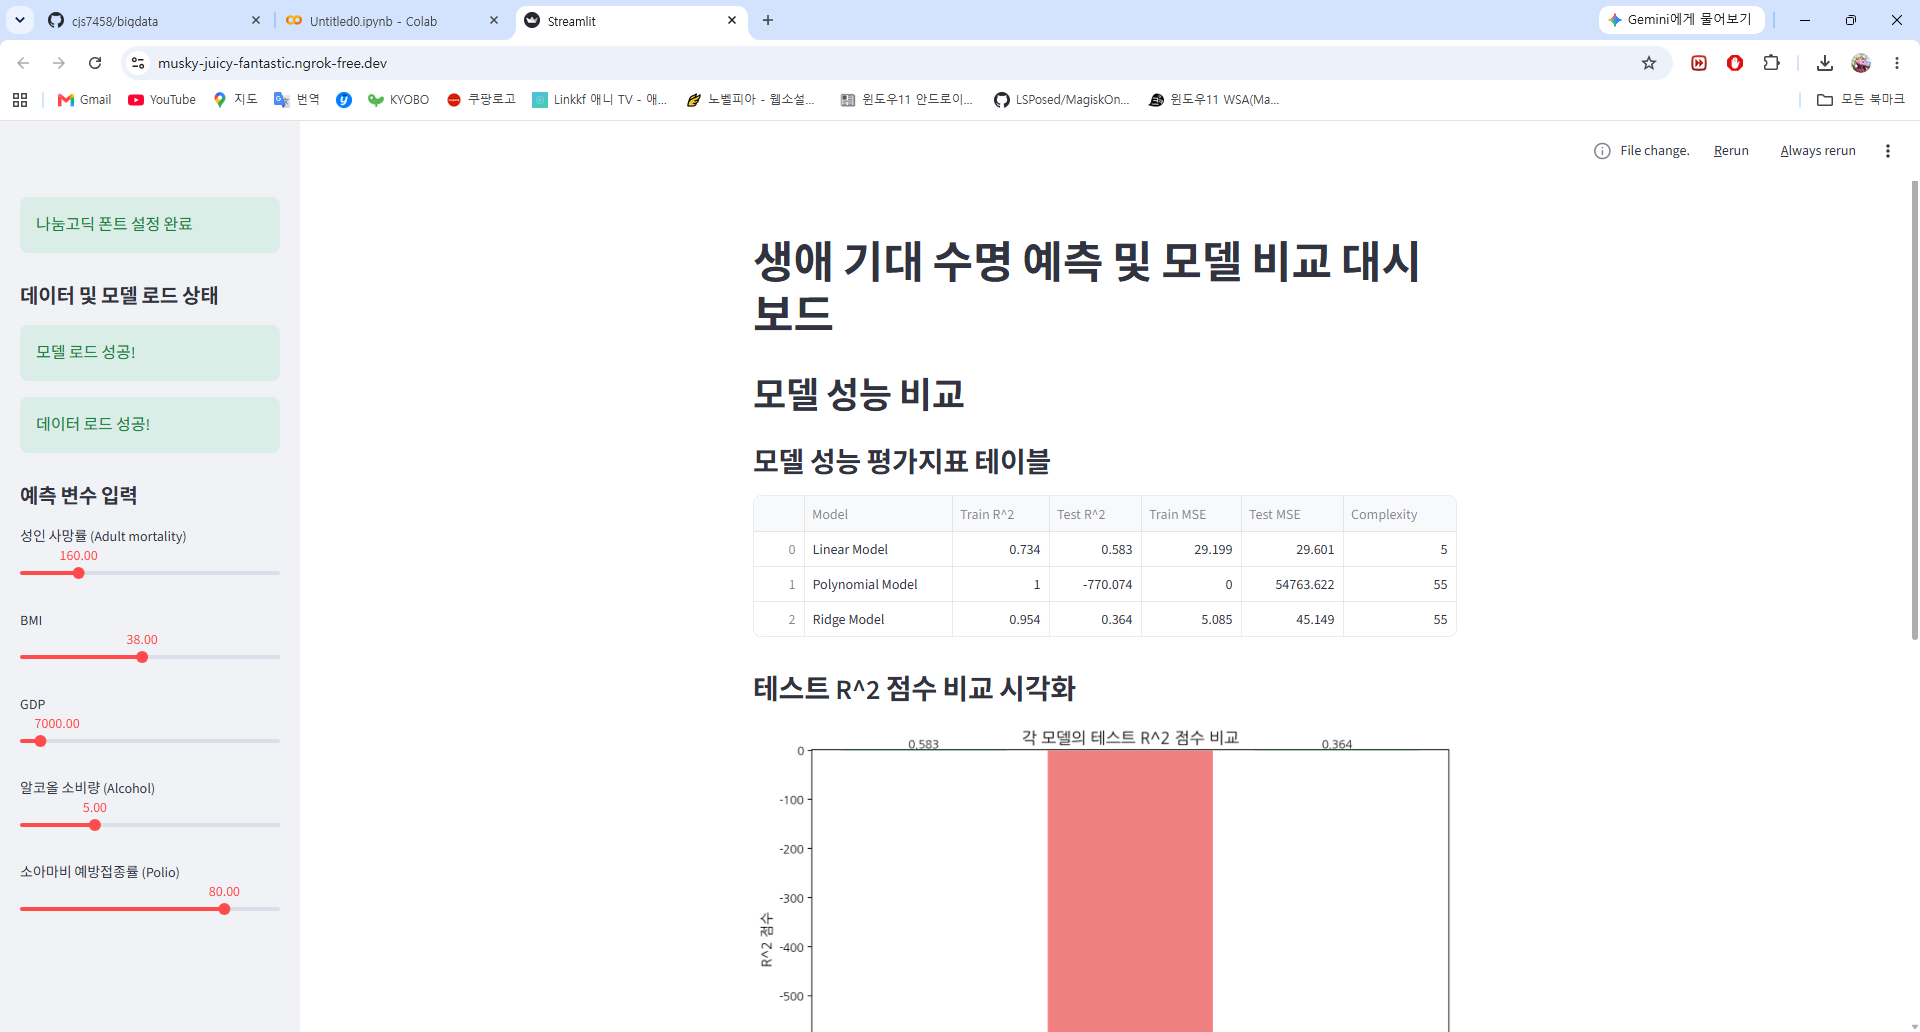